2026-09-21 14:14:48.811 | INFO     | __main__:node_a:10 - 当前步骤: 1
2026-09-21 14:14:48.822 | INFO     | __main__:node_b:14 - 当前步骤: 2
2026-09-21 14:14:48.829 | INFO     | __main__:node_c:18 - 当前步骤: 2
2026-09-21 14:14:48.833 | INFO     | __main__:node_d:22 - 当前步骤: 3
2026-09-21 14:14:48.835 | INFO     | __main__:node_e:26 - 当前步骤: 4


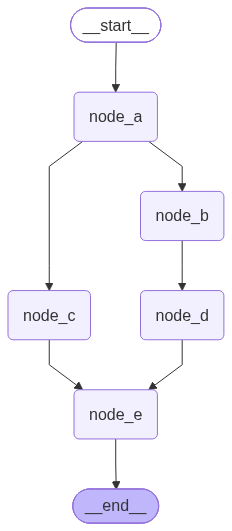

In [6]:
from typing import TypedDict
from loguru import logger
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END

class EmptyState(TypedDict):
    pass
def node_a(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step=config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}
def node_b(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step=config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}
def node_c(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step=config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}
def node_d(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step=config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}
def node_e(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step=config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}
builder=StateGraph(state_schema=EmptyState)
builder.add_node(node_a)
builder.add_node(node_c)
builder.add_node(node_d)
builder.add_node(node_e)
builder.add_node(node_b)


builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_a","node_c")
builder.add_edge("node_b","node_d")
#或节点扇入关系
# builder.add_edge("node_d","node_e")
# builder.add_edge("node_c","node_e")
#与节点扇入关系
builder.add_edge(["node_c","node_d"],"node_e")

builder.add_edge("node_e",END)


graph=builder.compile()
graph.invoke({})


display(graph)


